# Five sports, two levels of competition
**Football · Cricket · Basketball · Tennis · Volleyball**

An editorial selection of widely followed global sports, not an asserted universal top-five popularity ranking. This notebook examines **50 historical championship editions across 10 competitions**, five editions per competition. It is a curated championship dataset, not complete match or player coverage. The original IPL data is analysed separately.

Coverage ends at or before 2024; this is not a current-season dashboard. Most competitions are men’s; World TeamTennis is mixed-gender.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'analytics.py').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analytics import *
sns.set_theme(style='whitegrid', palette='colorblind')
data = load_championships()
coverage(data)

,sport,level,competition,category,editions,first_year,last_year,unique_champions
0,Basketball,Club / franchise,NBA,Men,5,2020,2024,5
1,Basketball,National team,FIBA Basketball World Cup,Men,5,2006,2023,3
2,Cricket,Club / franchise,Indian Premier League,Men,5,2015,2019,3
3,Cricket,National team,ICC T20 World Cup,Men,5,2014,2024,5
4,Football,Club / franchise,UEFA Champions League,Men,5,2020,2024,4
5,Football,National team,FIFA World Cup,Men,5,2006,2022,5
6,Tennis,Club / franchise,World TeamTennis,Mixed,5,2017,2021,3
7,Tennis,National team,Davis Cup,Men,5,2019,2024,4
8,Volleyball,Club / franchise,FIVB Club World Championship,Men,5,2017,2022,5
9,Volleyball,National team,FIVB World Championship,Men,5,2006,2022,3


## 1. Provenance and validation
Every row links to a result source. Required values, duplicate editions, sport/level/category labels, years, distinct finalists, and HTTPS source links are validated on load. There are no synthetic or forecast results. See `data/README.md` for selection and name-normalisation rules.

In [2]:
assert len(data) == 50
assert set(data.sport) == set(SPORTS)
assert data.groupby(['sport', 'level']).size().eq(5).all()
display(data.isna().sum().to_frame('missing'))
data.head()

,missing
sport,0
level,0
competition,0
category,0
year,0
champion,0
runner_up,0
source_url,0


,sport,level,competition,category,year,champion,runner_up,source_url
0,Basketball,Club / franchise,NBA,Men,2020,Los Angeles Lakers,Miami Heat,https://www.nba.com/news/finals-stat-lakers-he...
1,Basketball,Club / franchise,NBA,Men,2021,Milwaukee Bucks,Phoenix Suns,https://www.nba.com/playoffs/2021/the-finals
2,Basketball,Club / franchise,NBA,Men,2022,Golden State Warriors,Boston Celtics,https://www.nba.com/playoffs/2022/the-finals
3,Basketball,Club / franchise,NBA,Men,2023,Denver Nuggets,Miami Heat,https://www.nba.com/game/0042200405
4,Basketball,Club / franchise,NBA,Men,2024,Boston Celtics,Dallas Mavericks,https://www.nba.com/playoffs/2024/nba-finals


## 2. Choose a sport and observation window
Edit the values below and rerun. Keep level, competition and category distinct: a club final and a national final involve different populations and formats.

In [3]:
sport = 'Football'
start_year, end_year = 2006, 2024
selected = data[data.sport.eq(sport) & data.year.between(start_year, end_year)]
assert not selected.empty, 'Choose a range containing championship editions.'
summary = championship_summary(selected)
display(summary.round(1))

,sport,level,competition,category,team,finals,titles,runner_up_finishes,final_conversion_pct,editions,title_share_pct
0,Football,Club / franchise,UEFA Champions League,Men,Real Madrid,2,2,0,100.0,5,40.0
1,Football,National team,FIFA World Cup,Men,France,3,1,2,33.3,5,20.0
2,Football,National team,FIFA World Cup,Men,Argentina,2,1,1,50.0,5,20.0
3,Football,Club / franchise,UEFA Champions League,Men,Manchester City,2,1,1,50.0,5,20.0
4,Football,Club / franchise,UEFA Champions League,Men,Bayern Munich,1,1,0,100.0,5,20.0
5,Football,Club / franchise,UEFA Champions League,Men,Chelsea,1,1,0,100.0,5,20.0
6,Football,National team,FIFA World Cup,Men,Germany,1,1,0,100.0,5,20.0
7,Football,National team,FIFA World Cup,Men,Italy,1,1,0,100.0,5,20.0
8,Football,National team,FIFA World Cup,Men,Spain,1,1,0,100.0,5,20.0
9,Football,Club / franchise,UEFA Champions League,Men,Borussia Dortmund,1,0,1,0.0,5,0.0


## 3. Titles within the selected editions
Title share = titles / observed editions in that competition. Final conversion = titles / appearances in its final. Neither is a season-wide match win rate. Runners-up with no titles remain visible.

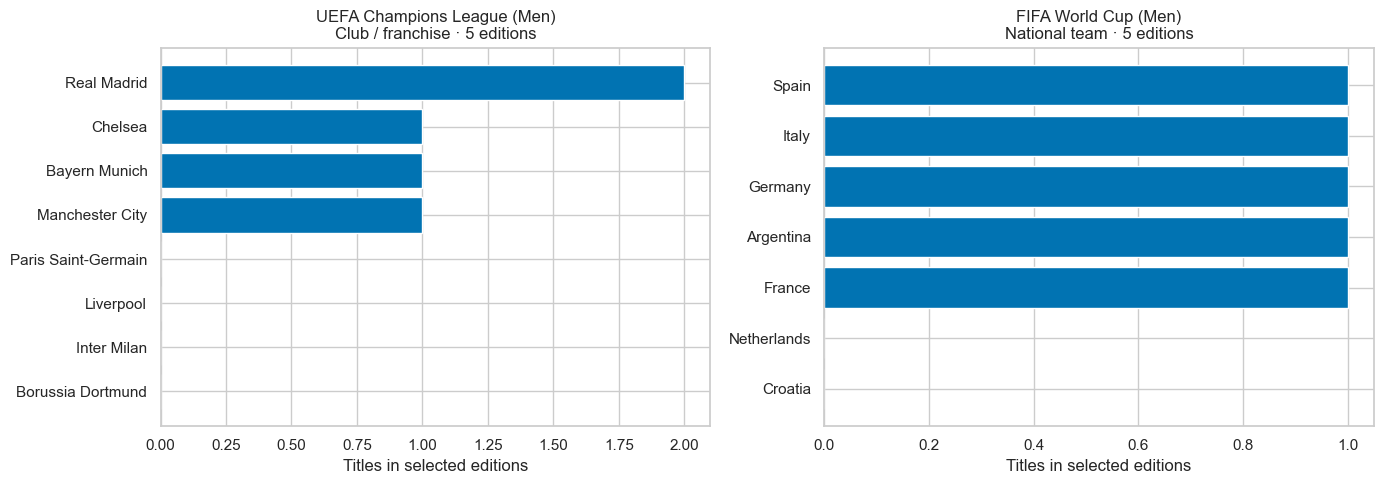

In [4]:
groups = list(selected.groupby(['level', 'competition', 'category']))
fig, axes = plt.subplots(1, len(groups), figsize=(7 * len(groups), 5), squeeze=False)
for ax, ((level, competition, category), subset) in zip(axes.flat, groups):
    ranks = championship_summary(subset).sort_values('titles')
    ax.barh(ranks.team, ranks.titles)
    ax.set_title(f'{competition} ({category})\n{level} · {len(subset)} editions')
    ax.set_xlabel('Titles in selected editions')
plt.tight_layout()
plt.show()

## 4. All five sports: concentration within each competition
The leading team’s title share measures concentration within this small sample. Different dates, tournament frequencies, qualification rules, and five-edition sample sizes make this an exploratory comparison—not a global team-strength ranking.

,sport,level,competition,category,leading_title_share_pct,editions
0,Basketball,Club / franchise,NBA,Men,20.0,5
1,Basketball,National team,FIBA Basketball World Cup,Men,40.0,5
2,Cricket,Club / franchise,Indian Premier League,Men,60.0,5
3,Cricket,National team,ICC T20 World Cup,Men,20.0,5
4,Football,Club / franchise,UEFA Champions League,Men,40.0,5
5,Football,National team,FIFA World Cup,Men,20.0,5
6,Tennis,Club / franchise,World TeamTennis,Mixed,40.0,5
7,Tennis,National team,Davis Cup,Men,40.0,5
8,Volleyball,Club / franchise,FIVB Club World Championship,Men,20.0,5
9,Volleyball,National team,FIVB World Championship,Men,40.0,5


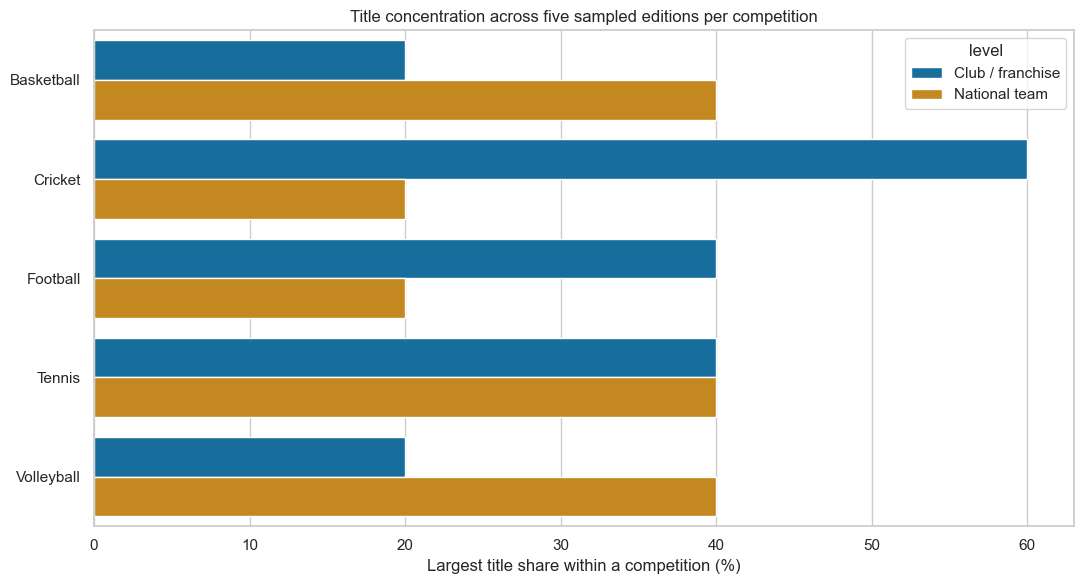

In [5]:
all_teams = championship_summary(data)
concentration = all_teams.groupby(GROUP).agg(leading_title_share_pct=('title_share_pct', 'max'), editions=('editions', 'first')).reset_index()
display(concentration)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=concentration, y='sport', x='leading_title_share_pct', hue='level', ax=ax)
ax.set_xlabel('Largest title share within a competition (%)')
ax.set_ylabel('')
ax.set_title('Title concentration across five sampled editions per competition')
plt.tight_layout()
plt.show()

## 5. Audit the result history
Year means the year the title was awarded, not the start year of a league season. An NBA row covers a championship series; a Davis Cup row covers a team tie. Score units are deliberately not pooled.

In [6]:
selected.sort_values(['level', 'year'])[['year', 'level', 'competition', 'category', 'champion', 'runner_up', 'source_url']]

,year,level,competition,category,champion,runner_up,source_url
20,2020,Club / franchise,UEFA Champions League,Men,Bayern Munich,Paris Saint-Germain,https://www.uefa.com/uefachampionsleague/histo...
21,2021,Club / franchise,UEFA Champions League,Men,Chelsea,Manchester City,https://www.uefa.com/uefachampionsleague/histo...
22,2022,Club / franchise,UEFA Champions League,Men,Real Madrid,Liverpool,https://www.uefa.com/uefachampionsleague/histo...
23,2023,Club / franchise,UEFA Champions League,Men,Manchester City,Inter Milan,https://www.uefa.com/uefachampionsleague/histo...
24,2024,Club / franchise,UEFA Champions League,Men,Real Madrid,Borussia Dortmund,https://www.uefa.com/uefachampionsleague/histo...
25,2006,National team,FIFA World Cup,Men,Italy,France,https://www.fifa.com/es/tournaments/mens/world...
26,2010,National team,FIFA World Cup,Men,Spain,Netherlands,https://www.fifa.com/es/tournaments/mens/world...
27,2014,National team,FIFA World Cup,Men,Germany,Argentina,https://www.fifa.com/es/tournaments/mens/world...
28,2018,National team,FIFA World Cup,Men,France,Croatia,https://www.fifa.com/es/tournaments/mens/world...
29,2022,National team,FIFA World Cup,Men,Argentina,France,https://www.fifa.com/es/tournaments/mens/world...


## 6. Export reproducible outputs
Reports are generated locally and ignored by Git. Use `python analytics.py` to export these and the IPL reports together. For a larger verified championship file, use `python analytics.py --championships path/to/file.csv` or upload it in the Streamlit explorer.

In [7]:
output = ROOT / 'reports'
output.mkdir(exist_ok=True)
all_teams.to_csv(output / 'championship_summary.csv', index=False)
coverage(data).to_csv(output / 'coverage.csv', index=False)
print(f'Exported championship summary and coverage to {output}')

Exported championship summary and coverage to /Users/harshitkotnala/Documents/ChatGPT/Sports/Exploratory-Data-Analysis-Sports/reports


## Limits and next data collection
These results do not cover all professional leagues, all nations, women-only tournaments, or complete fixture histories. To study form, home advantage, player efficiency, or full-season win rates beyond IPL, collect match/player data with competition-specific definitions and licences. Do not invent missing scores or infer participation from absence in this finals-only dataset.